<a href="https://colab.research.google.com/github/Prashkov1ch/python-ai-Prashkovich-Anna/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_Lab03_Economists_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 3 (экономисты): Визуализация в Matplotlib

**Ограничения:** основной упор на `matplotlib`. Допускается `numpy`. Никакого `pandas`.

**Цель:** построить базовые графики:
- линейные графики,
- диаграммы рассеяния,
- гистограммы,
- субграфики.

In [1]:
import re
from openpyxl import load_workbook
import numpy as np  # ← Важно: импорт numpy
import os
from google.colab import drive

# Монтируем диск (с защитой от повторного монтирования)
try:
    drive.mount('/content/drive')
except:
    pass

PATH = '/content/drive/MyDrive/цифровая кафедра/'  # Проверь, что имя папки верное!
os.chdir(PATH)

FILES = ['Копия 1 Атомэнергопром.xlsx', 'Копия 2 Аэрофлот.xlsx', 'Копия 3 Газпром_петрозаводск.xlsx',
         'Копия 4 Лукойл.xlsx', 'Копия 5 Роснефть.xlsx', 'Копия 6 Самолет.xlsx',
         'Копия 7 Славмо.xlsx', 'Копия 8 Строительная_компания_Век.xlsx',
         'Копия 9 ТГК_1.xlsx', 'Копия 10 ТНС_ЭНЭРГО_Карелия.xlsx']

# --- ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ ДЛЯ ОЧИСТКИ ЧИСЕЛ ---
def clean_number(value):
    """
    Превращает значение из Excel в число float.
    Удаляет пробелы из строк вида '1 000 000'.
    Если значение пустое — возвращает np.nan.
    """
    if value is None:
        return np.nan
    # Превращаем в строку и убираем все пробелы
    s = str(value).replace(' ', '')
    try:
        return float(s)
    except:
        return np.nan

def org_name(xlsx_name: str):
    wb = load_workbook(xlsx_name, data_only=True)
    ws = wb["Сведения об организации"]
    return str(ws.cell(row=6, column=13).value)

def parse_financial(xlsx_name: str):
    wb = load_workbook(xlsx_name, data_only=True)
    ws = wb["Отчет о финансовых результатах"]
    res = {}
    for r in range(6, 200):
        code = ws.cell(r, 16).value
        if code is None:
            continue
        code = str(code).strip()
        if not re.fullmatch(r"\d{4}", code):
            continue
        v23 = ws.cell(r, 21).value
        v22 = ws.cell(r, 27).value
        # ИСПРАВЛЕНИЕ: используем clean_number для очистки данных
        res[code] = (clean_number(v22), clean_number(v23))  # (2022, 2023)
    return res

names = [org_name(fn) for fn in FILES]

revenue = []
net_profit = []

for fn in FILES:
    fin = parse_financial(fn)
    # Теперь данные уже очищены функцией clean_number
    revenue.append(fin.get("2110", (np.nan, np.nan)))
    net_profit.append(fin.get("2400", (np.nan, np.nan)))

# Преобразуем списки в NumPy-массивы
revenue = np.array(revenue, dtype=float)       # (n,2)
net_profit = np.array(net_profit, dtype=float) # (n,2)
years = np.array([2022, 2023])

print("✅ Данные успешно загружены и очищены!")
print("Loaded arrays: ", revenue.shape, net_profit.shape)

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


✅ Данные успешно загружены и очищены!
Loaded arrays:  (10, 2) (10, 2)


### Задание 1
Постройте линейный график суммарной выручки по годам (сумма по компаниям).  
Ось X — годы, ось Y — сумма выручки.

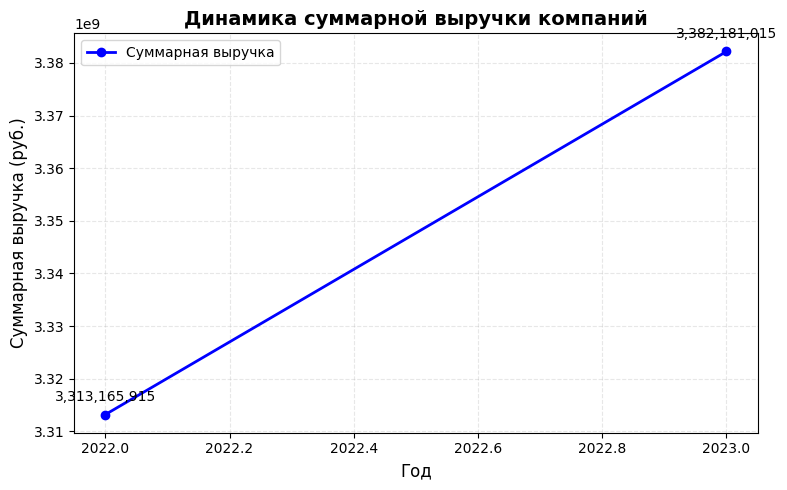

📊 Суммарная выручка:
  2022 год: 3,313,165,915 руб.
  2023 год: 3,382,181,015 руб.
  Изменение: +69,015,100 руб.


In [2]:
# Задание 1: Линейный график суммарной выручки по годам

# 1. Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# 2. Рассчитываем суммарную выручку по годам
# Используем np.nansum, чтобы игнорировать NaN значения при суммировании
# revenue[:, 0] — выручка за 2022 год (все компании, столбец 0)
# revenue[:, 1] — выручка за 2023 год (все компании, столбец 1)
total_revenue_2022 = np.nansum(revenue[:, 0])
total_revenue_2023 = np.nansum(revenue[:, 1])
total_revenue = [total_revenue_2022, total_revenue_2023]

# 3. Создаём фигуру и оси для графика
plt.figure(figsize=(8, 5))  # Размер графика: 8×5 дюймов

# 4. Строим линейный график
# years — значения по оси X ([2022, 2023])
# total_revenue — значения по оси Y (суммы выручки)
# marker='o' — добавляет точки на линию
# linewidth=2 — толщина линии
# color='blue' — цвет линии
plt.plot(years, total_revenue, marker='o', linewidth=2, color='blue', label='Суммарная выручка')

# 5. Добавляем подписи осей и заголовок
plt.xlabel('Год', fontsize=12)                    # Подпись оси X
plt.ylabel('Суммарная выручка (руб.)', fontsize=12)  # Подпись оси Y
plt.title('Динамика суммарной выручки компаний', fontsize=14, fontweight='bold')  # Заголовок

# 6. Добавляем сетку для удобства чтения
plt.grid(True, alpha=0.3, linestyle='--')  # alpha — прозрачность сетки

# 7. Добавляем подписи значений над точками
for i, (year, val) in enumerate(zip(years, total_revenue)):
    plt.annotate(f'{val:,.0f}',
                 xy=(year, val),
                 xytext=(0, 10),  # смещение текста на 10 пикселей вверх
                 textcoords='offset points',
                 ha='center',      # горизонтальное выравнивание по центру
                 fontsize=10)

# 8. Добавляем легенду
plt.legend(fontsize=10)

# 9. Оптимизируем расположение элементов, чтобы ничего не обрезалось
plt.tight_layout()

# 10. Показываем график
plt.show()

# 11. Выводим числовые значения для справки
print("📊 Суммарная выручка:")
print(f"  2022 год: {total_revenue_2022:,.0f} руб.")
print(f"  2023 год: {total_revenue_2023:,.0f} руб.")
# ИСПРАВЛЕНИЕ: было :+,+,.0f (две запятые), стало :+,.0f (одна запятая)
print(f"  Изменение: {total_revenue_2023 - total_revenue_2022:+,.0f} руб.")

### Задание 2
Постройте несколько линий: выручка каждой компании по годам (10 линий).  
Легенду упростите: используйте первые 15 символов названия.

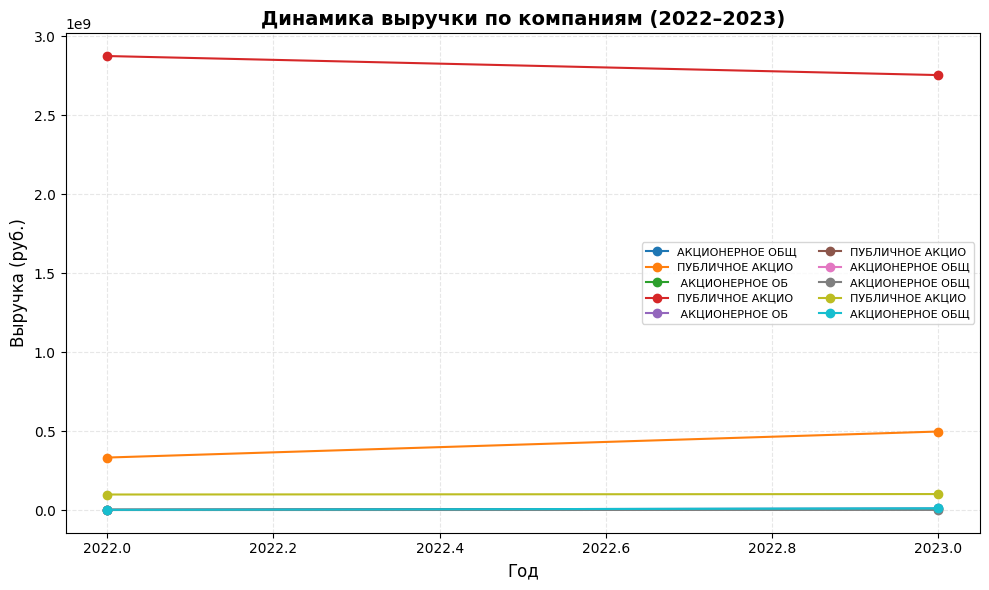

📊 Построено линий: 10
📋 Примеры сокращённых названий в легенде:
  1. 'АКЦИОНЕРНОЕ ОБЩ...' ← 'АКЦИОНЕРНОЕ ОБЩЕСТВО "АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫЙ КОМПЛЕКС"'
  2. 'ПУБЛИЧНОЕ АКЦИО...' ← 'ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "АЭРОФЛОТ-РОССИЙСКИЕ АВИАЛИНИИ"'
  3. ' АКЦИОНЕРНОЕ ОБ...' ← ' АКЦИОНЕРНОЕ ОБЩЕСТВО "ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕНИЕ ПЕТРОЗАВОДСК"'


In [14]:
# Задание 2: Выручка каждой компании по годам (10 линий)

# 1. Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# 2. Создаём фигуру с подходящим размером
plt.figure(figsize=(10, 6))

# 3. Проходим по каждой компании и строим отдельную линию
for i in range(len(names)):
    # Выручка текущей компании за 2022 и 2023 годы
    company_revenue = revenue[i, :]  # [выручка_2022, выручка_2023]

    # Упрощаем название: берём первые 15 символов для легенды
    short_name = names[i][:15]

    # Строим линию для этой компании
    plt.plot(years, company_revenue, marker='o', label=short_name, linewidth=1.5)

# 4. Добавляем подписи осей и заголовок
plt.xlabel('Год', fontsize=12)
plt.ylabel('Выручка (руб.)', fontsize=12)
plt.title('Динамика выручки по компаниям (2022–2023)', fontsize=14, fontweight='bold')

# 5. Добавляем сетку для удобства чтения
plt.grid(True, alpha=0.3, linestyle='--')

# 6. Добавляем легенду с упрощёнными названиями
# loc='best' — matplotlib сам выберет лучшее место для легенды
# fontsize=8 — уменьшаем шрифт, чтобы легенда помещалась
plt.legend(loc='best', fontsize=8, ncol=2)

# 7. Оптимизируем расположение элементов
plt.tight_layout()

# 8. Показываем график
plt.show()

# 9. Выводим справку о том, что отображено
print("📊 Построено линий:", len(names))
print("📋 Примеры сокращённых названий в легенде:")
for i, name in enumerate(names[:3], 1):
    print(f"  {i}. '{name[:15]}...' ← '{name}'")

### Задание 3
Постройте scatter: выручка 2023 (X) vs чистая прибыль 2023 (Y).  
Добавьте линии осей x=0 и y=0.

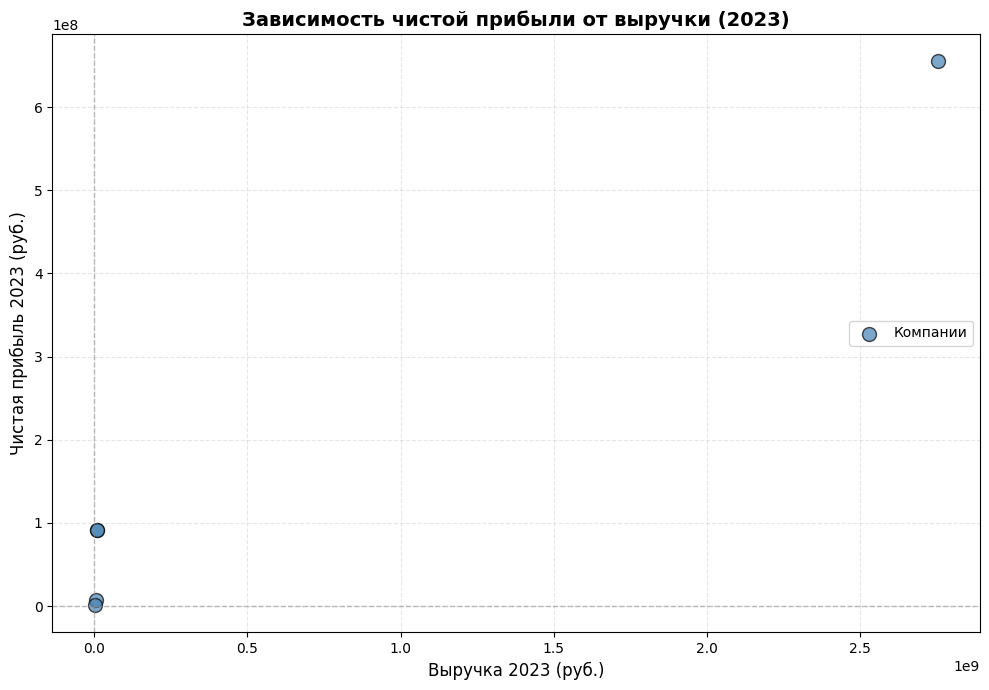

📊 Статистика данных (2023):
  Компаний с данными: 5
  Выручка: мин=1,318,962, макс=2,753,475,003
  Прибыль: мин=870,349, макс=655,289,456


In [15]:
# Задание 3: Scatter-график: выручка 2023 (X) vs чистая прибыль 2023 (Y)

# 1. Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# 2. Извлекаем данные за 2023 год (столбец с индексом 1)
revenue_2023 = revenue[:, 1]      # Ось X
net_profit_2023 = net_profit[:, 1]  # Ось Y

# 3. Создаём фигуру с подходящим размером
plt.figure(figsize=(10, 7))

# 4. Строим scatter-график
# s=100 — размер точек, alpha=0.7 — полупрозрачность для лучшей видимости
# color='steelblue' — цвет точек, edgecolors='black' — чёрная обводка
plt.scatter(revenue_2023, net_profit_2023,
            s=100, alpha=0.7, color='steelblue', edgecolors='black',
            label='Компании')

# 5. Добавляем линии осей в точке 0
# axvline — вертикальная линия (x=0), axhline — горизонтальная (y=0)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# 6. Добавляем подписи осей и заголовок
plt.xlabel('Выручка 2023 (руб.)', fontsize=12)
plt.ylabel('Чистая прибыль 2023 (руб.)', fontsize=12)
plt.title('Зависимость чистой прибыли от выручки (2023)', fontsize=14, fontweight='bold')

# 7. Добавляем сетку для удобства чтения
plt.grid(True, alpha=0.3, linestyle='--')

# 8. Добавляем легенду
plt.legend(fontsize=10)

# 9. Оптимизируем расположение элементов
plt.tight_layout()

# 10. Показываем график
plt.show()

# 11. Выводим статистику для справки
print("📊 Статистика данных (2023):")
print(f"  Компаний с данными: {np.sum(~np.isnan(revenue_2023) & ~np.isnan(net_profit_2023))}")
print(f"  Выручка: мин={np.nanmin(revenue_2023):,.0f}, макс={np.nanmax(revenue_2023):,.0f}")
print(f"  Прибыль: мин={np.nanmin(net_profit_2023):,.0f}, макс={np.nanmax(net_profit_2023):,.0f}")

### Задание 4
Подпишите на scatter-графике 3 компании с максимальной выручкой 2023 (annotate).

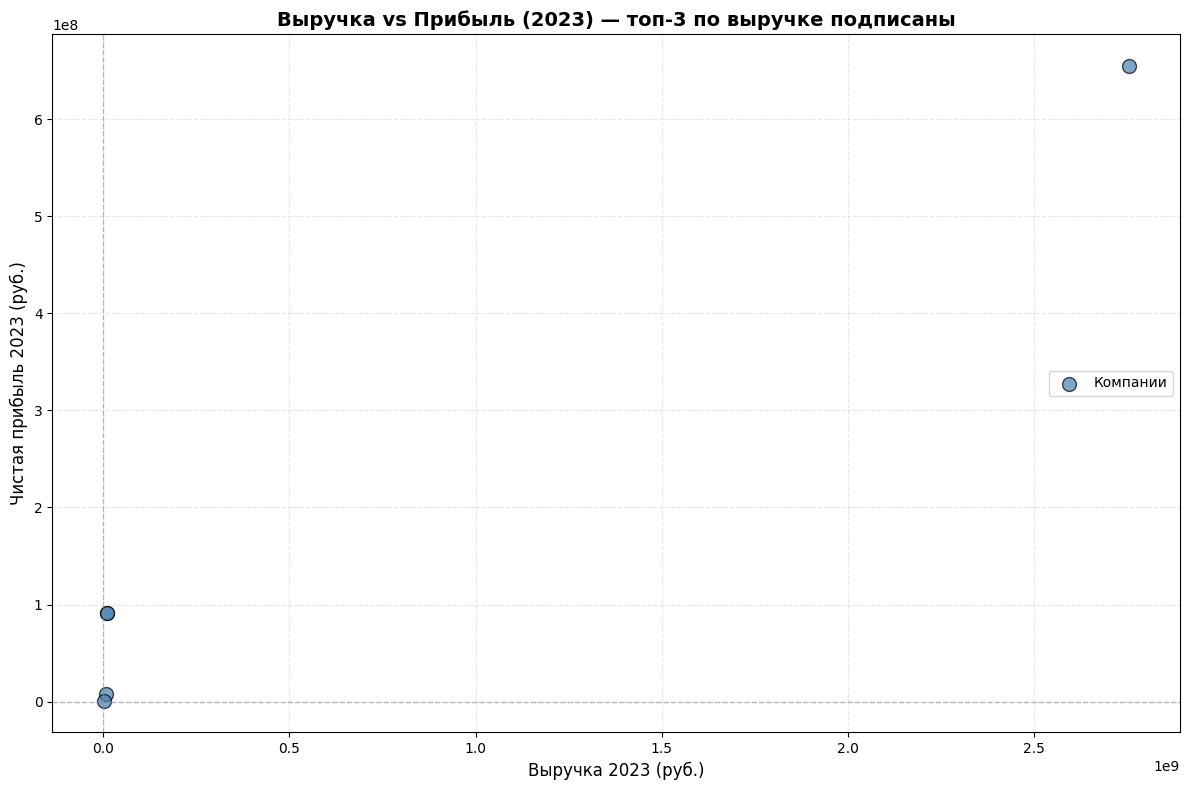

🏆 Топ-3 компании по выручке 2023 (подписаны на графике):


In [16]:
# Задание 4: Подписываем топ-3 компании по выручке 2023 на scatter-графике

# 1. Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# 2. Извлекаем данные за 2023 год (столбец с индексом 1)
revenue_2023 = revenue[:, 1]      # Ось X
net_profit_2023 = net_profit[:, 1]  # Ось Y

# 3. Создаём фигуру с подходящим размером
plt.figure(figsize=(12, 8))

# 4. Строим scatter-график
plt.scatter(revenue_2023, net_profit_2023,
            s=100, alpha=0.7, color='steelblue', edgecolors='black',
            label='Компании')

# 5. Добавляем линии осей в точке 0
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# 6. Находим индексы 3 компаний с максимальной выручкой 2023
# np.argsort возвращает индексы, которые отсортировали бы массив по возрастанию
# Берём последние 3 индекса и переворачиваем порядок (по убыванию)
top3_indices = np.argsort(revenue_2023)[-3:][::-1]

# 7. Подписываем топ-3 компании с помощью annotate
for idx in top3_indices:
    # Пропускаем компании с отсутствующими данными
    if np.isnan(revenue_2023[idx]) or np.isnan(net_profit_2023[idx]):
        continue

    # Упрощаем название для подписи (первые 20 символов)
    short_name = names[idx][:20] + '...' if len(names[idx]) > 20 else names[idx]

    # Добавляем аннотацию
    plt.annotate(short_name,
                 xy=(revenue_2023[idx], net_profit_2023[idx]),  # Координаты точки
                 xytext=(10, 10),  # Смещение текста от точки (в пикселях)
                 textcoords='offset points',  # Единицы измерения смещения
                 fontsize=9,  # Размер шрифта
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),  # Фон подписи
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', color='red'))  # Стрелка

# 8. Добавляем подписи осей и заголовок
plt.xlabel('Выручка 2023 (руб.)', fontsize=12)
plt.ylabel('Чистая прибыль 2023 (руб.)', fontsize=12)
plt.title('Выручка vs Прибыль (2023) — топ-3 по выручке подписаны', fontsize=14, fontweight='bold')

# 9. Добавляем сетку и легенду
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)

# 10. Оптимизируем расположение элементов
plt.tight_layout()

# 11. Показываем график
plt.show()

# 12. Выводим информацию о подписанных компаниях для справки
print("🏆 Топ-3 компании по выручке 2023 (подписаны на графике):")
for rank, idx in enumerate(top3_indices, 1):
    if not np.isnan(revenue_2023[idx]):
        print(f"  {rank}. {names[idx]}")
        print(f"     Выручка: {revenue_2023[idx]:,.0f} руб.")
        print(f"     Прибыль: {net_profit_2023[idx]:,.0f} руб.")

### Задание 5
Постройте гистограмму распределения выручки 2023 по компаниям (bins=10).

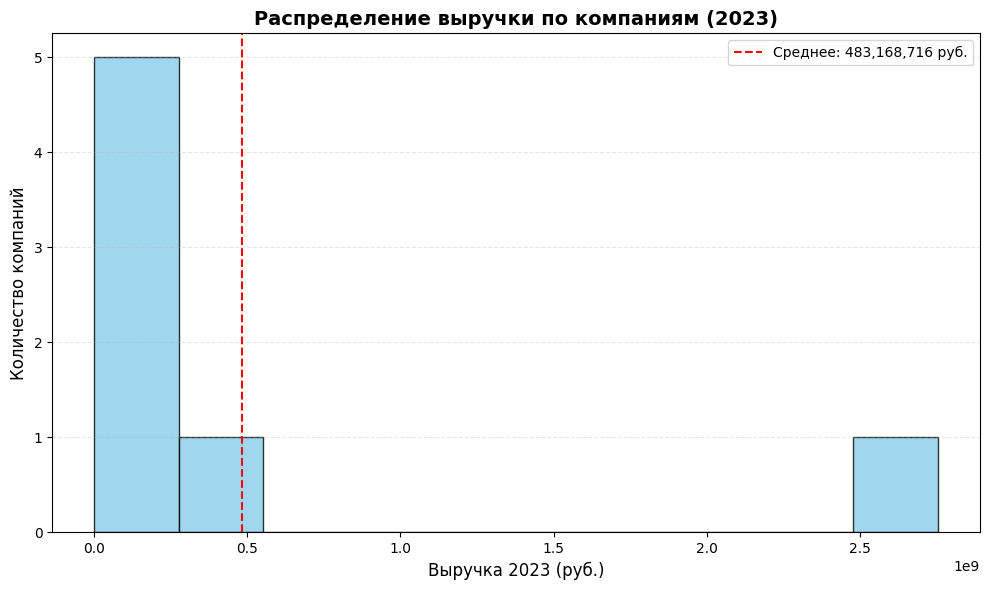

📊 Статистика выручки 2023:
  Компаний с данными: 7
  Минимум: 1,318,962 руб.
  Максимум: 2,753,475,003 руб.
  Среднее: 483,168,716 руб.
  Медиана: 10,667,978 руб.


In [17]:
# Задание 5: Гистограмма распределения выручки 2023 по компаниям

# 1. Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# 2. Извлекаем выручку за 2023 год (столбец с индексом 1)
revenue_2023 = revenue[:, 1]

# 3. Удаляем NaN значения для корректного построения гистограммы
# np.isnan() возвращает True для пропущенных значений
# ~ означает логическое НЕ, поэтому ~np.isnan() = "не является пропуском"
revenue_valid = revenue_2023[~np.isnan(revenue_2023)]

# 4. Создаём фигуру с подходящим размером
plt.figure(figsize=(10, 6))

# 5. Строим гистограмму
# revenue_valid — данные для построения
# bins=10 — разбиваем диапазон значений на 10 интервалов
# color='skyblue' — цвет столбцов
# edgecolor='black' — чёрная обводка столбцов для лучшей видимости
# alpha=0.8 — небольшая прозрачность
plt.hist(revenue_valid, bins=10, color='skyblue', edgecolor='black', alpha=0.8)

# 6. Добавляем подписи осей и заголовок
plt.xlabel('Выручка 2023 (руб.)', fontsize=12)
plt.ylabel('Количество компаний', fontsize=12)
plt.title('Распределение выручки по компаниям (2023)', fontsize=14, fontweight='bold')

# 7. Добавляем сетку по оси Y для удобства чтения
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 8. Добавляем вертикальную линию среднего значения
mean_rev = np.mean(revenue_valid)
plt.axvline(mean_rev, color='red', linestyle='--', linewidth=1.5,
            label=f'Среднее: {mean_rev:,.0f} руб.')

# 9. Добавляем легенду
plt.legend(fontsize=10)

# 10. Оптимизируем расположение элементов
plt.tight_layout()

# 11. Показываем график
plt.show()

# 12. Выводим статистику для справки
print("📊 Статистика выручки 2023:")
print(f"  Компаний с данными: {len(revenue_valid)}")
print(f"  Минимум: {np.min(revenue_valid):,.0f} руб.")
print(f"  Максимум: {np.max(revenue_valid):,.0f} руб.")
print(f"  Среднее: {np.mean(revenue_valid):,.0f} руб.")
print(f"  Медиана: {np.median(revenue_valid):,.0f} руб.")

### Задание 6
Постройте гистограмму распределения чистой прибыли 2023.  
Отдельно выведите долю компаний с отрицательной прибылью.

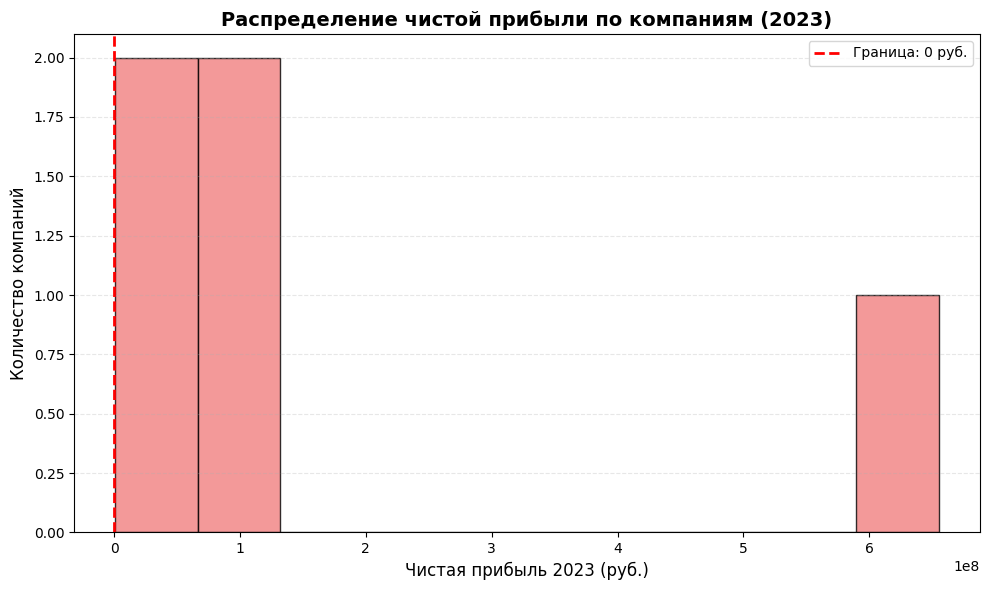

📊 Статистика чистой прибыли 2023:
  Компаний с данными: 5
  Компаний с убытком (< 0): 0
  Компаний с прибылью (≥ 0): 5
  📉 Доля компаний с отрицательной прибылью: 0.0%

  Минимум: 870,349 руб.
  Максимум: 655,289,456 руб.
  Среднее: 169,362,987 руб.
  Медиана: 91,493,932 руб.


In [18]:
# Задание 6: Гистограмма распределения чистой прибыли 2023

# 1. Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# 2. Извлекаем чистую прибыль за 2023 год (столбец с индексом 1)
net_profit_2023 = net_profit[:, 1]

# 3. Фильтруем данные: убираем NaN значения
# ~np.isnan() означает "НЕ является пропуском"
profit_valid = net_profit_2023[~np.isnan(net_profit_2023)]

# 4. Создаём фигуру с подходящим размером
plt.figure(figsize=(10, 6))

# 5. Строим гистограмму
# profit_valid — данные для построения
# bins=10 — разбиваем диапазон на 10 интервалов
# color='lightcoral' — цвет столбцов (красноватый для прибыли/убытка)
# edgecolor='black' — чёрная обводка для чёткости
# alpha=0.8 — небольшая прозрачность
plt.hist(profit_valid, bins=10, color='lightcoral', edgecolor='black', alpha=0.8)

# 6. Добавляем вертикальную линию в точке 0 (граница прибыли/убытка)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Граница: 0 руб.')

# 7. Добавляем подписи осей и заголовок
plt.xlabel('Чистая прибыль 2023 (руб.)', fontsize=12)
plt.ylabel('Количество компаний', fontsize=12)
plt.title('Распределение чистой прибыли по компаниям (2023)', fontsize=14, fontweight='bold')

# 8. Добавляем сетку по оси Y для удобства чтения
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 9. Добавляем легенду
plt.legend(fontsize=10)

# 10. Оптимизируем расположение элементов
plt.tight_layout()

# 11. Показываем график
plt.show()

# 12. Вычисляем и выводим долю компаний с отрицательной прибылью
# Считаем количество компаний с прибылью < 0
negative_profit_count = np.sum(profit_valid < 0)
total_count = len(profit_valid)
negative_share = negative_profit_count / total_count if total_count > 0 else 0

print("📊 Статистика чистой прибыли 2023:")
print(f"  Компаний с данными: {total_count}")
print(f"  Компаний с убытком (< 0): {negative_profit_count}")
print(f"  Компаний с прибылью (≥ 0): {total_count - negative_profit_count}")
print(f"  📉 Доля компаний с отрицательной прибылью: {negative_share:.1%}")
print(f"\n  Минимум: {np.min(profit_valid):,.0f} руб.")
print(f"  Максимум: {np.max(profit_valid):,.0f} руб.")
print(f"  Среднее: {np.mean(profit_valid):,.0f} руб.")
print(f"  Медиана: {np.median(profit_valid):,.0f} руб.")

### Задание 7
Сделайте субграфики 2×2:
1) Σ выручка по годам (line)  
2) Σ прибыль по годам (line)  
3) scatter 2023 (выручка–прибыль)  
4) гистограмма выручки 2023.

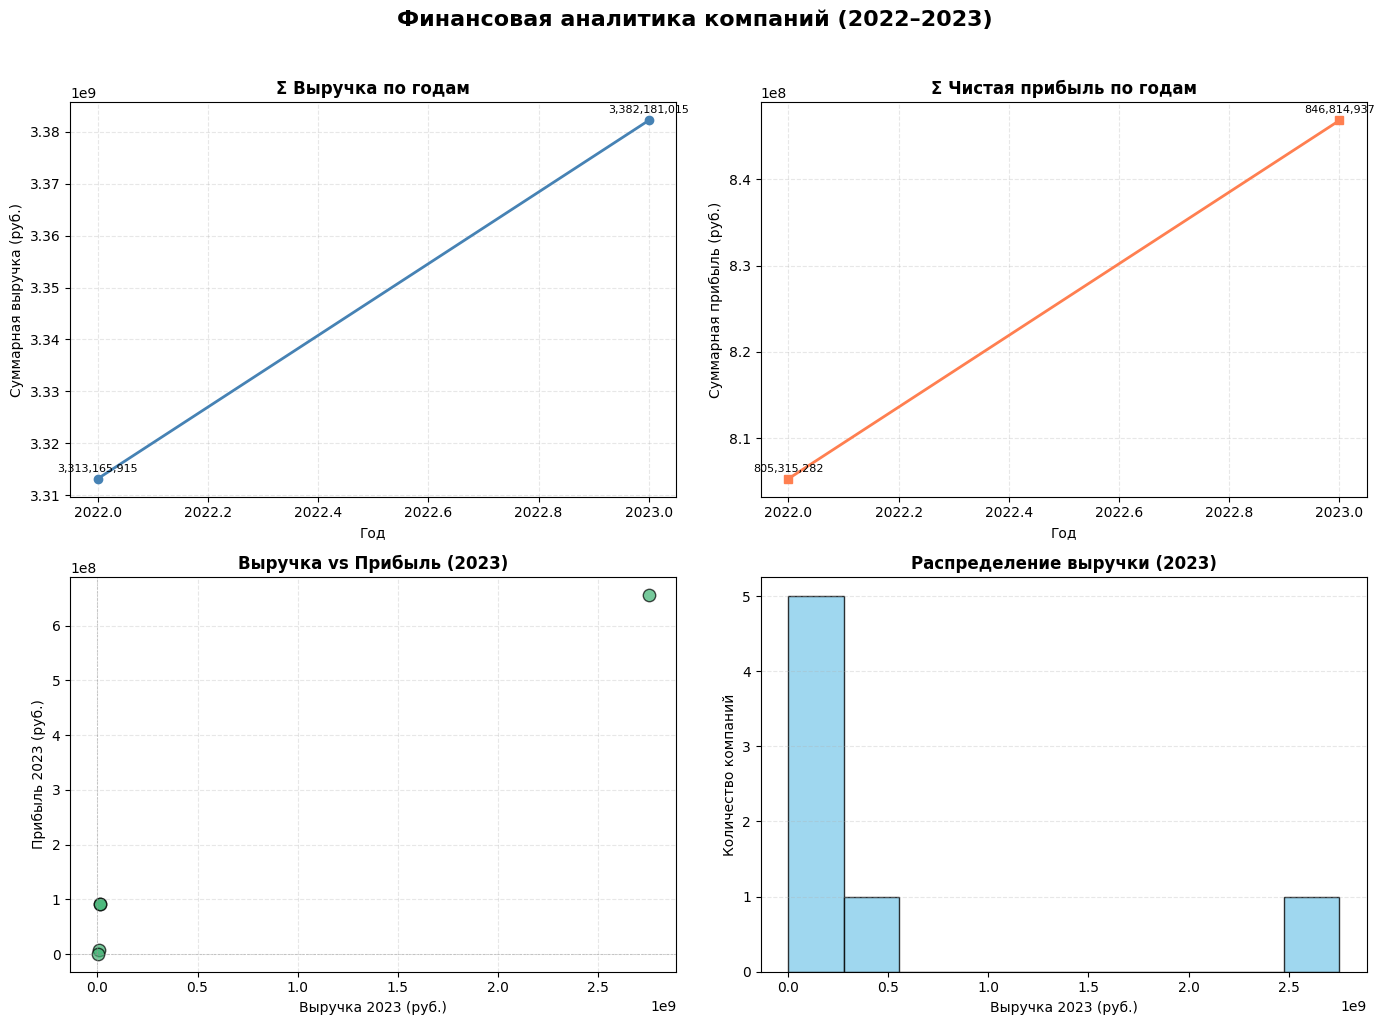

📊 Краткая статистика:
  Σ Выручка 2022: 3,313,165,915 руб.
  Σ Выручка 2023: 3,382,181,015 руб.
  Σ Прибыль 2022: 805,315,282 руб.
  Σ Прибыль 2023: 846,814,937 руб.
  Компаний с данными (2023): 7 из 10


In [19]:
# Задание 7: Субграфики 2×2

# 1. Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# 2. Создаём фигуру с 4 субграфиками (2 строки × 2 столбца)
# figsize=(14, 10) — большой размер, чтобы все графики были читаемыми
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# =====================================================
# График 1 (верхний левый): Σ выручка по годам (line)
# =====================================================
ax1 = axes[0, 0]
total_revenue = [np.nansum(revenue[:, 0]), np.nansum(revenue[:, 1])]
ax1.plot(years, total_revenue, marker='o', linewidth=2, color='steelblue')
ax1.set_xlabel('Год', fontsize=10)
ax1.set_ylabel('Суммарная выручка (руб.)', fontsize=10)
ax1.set_title('Σ Выручка по годам', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
# Добавляем подписи значений
for year, val in zip(years, total_revenue):
    ax1.annotate(f'{val:,.0f}', xy=(year, val), xytext=(0, 5),
                 textcoords='offset points', ha='center', fontsize=8)

# =====================================================
# График 2 (верхний правый): Σ прибыль по годам (line)
# =====================================================
ax2 = axes[0, 1]
total_profit = [np.nansum(net_profit[:, 0]), np.nansum(net_profit[:, 1])]
ax2.plot(years, total_profit, marker='s', linewidth=2, color='coral')
ax2.set_xlabel('Год', fontsize=10)
ax2.set_ylabel('Суммарная прибыль (руб.)', fontsize=10)
ax2.set_title('Σ Чистая прибыль по годам', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
# Добавляем подписи значений
for year, val in zip(years, total_profit):
    ax2.annotate(f'{val:,.0f}', xy=(year, val), xytext=(0, 5),
                 textcoords='offset points', ha='center', fontsize=8)

# =====================================================
# График 3 (нижний левый): scatter 2023 (выручка–прибыль)
# =====================================================
ax3 = axes[1, 0]
revenue_2023 = revenue[:, 1]
profit_2023 = net_profit[:, 1]
# Фильтруем валидные данные для scatter
mask = ~np.isnan(revenue_2023) & ~np.isnan(profit_2023)
ax3.scatter(revenue_2023[mask], profit_2023[mask],
            s=80, alpha=0.7, color='mediumseagreen', edgecolors='black')
# Добавляем линии осей в нуле
ax3.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax3.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax3.set_xlabel('Выручка 2023 (руб.)', fontsize=10)
ax3.set_ylabel('Прибыль 2023 (руб.)', fontsize=10)
ax3.set_title('Выручка vs Прибыль (2023)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')

# =====================================================
# График 4 (нижний правый): гистограмма выручки 2023
# =====================================================
ax4 = axes[1, 1]
revenue_valid_2023 = revenue_2023[~np.isnan(revenue_2023)]
ax4.hist(revenue_valid_2023, bins=10, color='skyblue', edgecolor='black', alpha=0.8)
ax4.set_xlabel('Выручка 2023 (руб.)', fontsize=10)
ax4.set_ylabel('Количество компаний', fontsize=10)
ax4.set_title('Распределение выручки (2023)', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# =====================================================
# Общие настройки для всех субграфиков
# =====================================================
# Добавляем общий заголовок для всей фигуры
fig.suptitle('Финансовая аналитика компаний (2022–2023)',
             fontsize=16, fontweight='bold', y=1.02)

# Автоматически подгоняем отступы, чтобы подписи не обрезались
plt.tight_layout()

# Показываем график
plt.show()

# Выводим краткую статистику для справки
print("📊 Краткая статистика:")
print(f"  Σ Выручка 2022: {total_revenue[0]:,.0f} руб.")
print(f"  Σ Выручка 2023: {total_revenue[1]:,.0f} руб.")
print(f"  Σ Прибыль 2022: {total_profit[0]:,.0f} руб.")
print(f"  Σ Прибыль 2023: {total_profit[1]:,.0f} руб.")
print(f"  Компаний с данными (2023): {len(revenue_valid_2023)} из {len(revenue_2023)}")

### Задание 8
Постройте бар-диаграмму: топ-5 компаний по выручке 2023 (по убыванию).

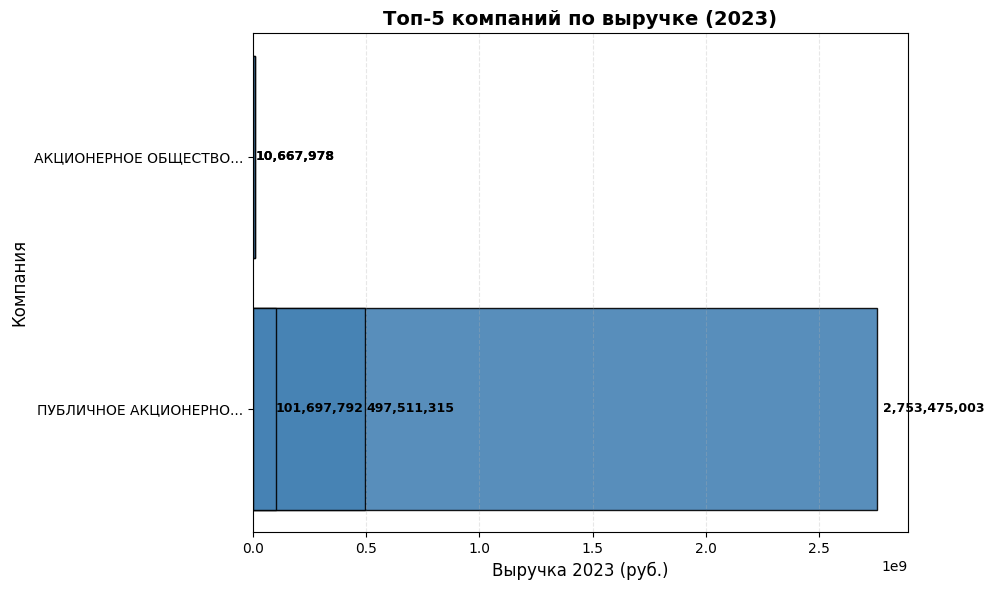

🏆 Топ-5 компаний по выручке 2023:
  1. ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "НЕФТЯНАЯ КОМПАНИЯ "ЛУКОЙЛ"
     Выручка: 2,753,475,003 руб.
  2. ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "АЭРОФЛОТ-РОССИЙСКИЕ АВИАЛИНИИ"
     Выручка: 497,511,315 руб.
  3. ПУБЛИЧНОЕ АКЦИОНЕРНОЕ  ОБЩЕСТВО  "ТЕРРИТОРИАЛЬНАЯ  ГЕНЕРИРУЮЩАЯ  КОМПАНИЯ   №1"
     Выручка: 101,697,792 руб.
  4. АКЦИОНЕРНОЕ ОБЩЕСТВО "АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫЙ КОМПЛЕКС"
     Выручка: 10,667,978 руб.
  5. АКЦИОНЕРНОЕ ОБЩЕСТВО "АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫЙ КОМПЛЕКС"
     Выручка: 10,667,978 руб.


In [20]:
# Задание 8: Бар-диаграмма топ-5 компаний по выручке 2023

# 1. Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# 2. Извлекаем выручку за 2023 год (столбец с индексом 1)
revenue_2023 = revenue[:, 1]

# 3. Создаём маску валидных данных (убираем NaN)
valid_mask = ~np.isnan(revenue_2023)
valid_indices = np.where(valid_mask)[0]

# 4. Проверяем, достаточно ли данных
if len(valid_indices) == 0:
    print("⚠️ Нет данных о выручке ни для одной компании!")
else:
    # 5. Находим индексы топ-5 компаний по выручке (по убыванию)
    # argsort сортирует по возрастанию, поэтому берём последние 5 и переворачиваем
    valid_revenue = revenue_2023[valid_indices]
    sorted_indices = np.argsort(valid_revenue)
    top5_local = sorted_indices[-5:][::-1]  # топ-5 по убыванию
    top5_global = valid_indices[top5_local]  # преобразуем в глобальные индексы

    # 6. Извлекаем названия и значения для топ-5
    top5_names = [names[idx] for idx in top5_global]
    top5_values = [revenue_2023[idx] for idx in top5_global]

    # 7. Упрощаем названия для отображения на графике (первые 20 символов)
    top5_short_names = [name[:20] + '...' if len(name) > 20 else name for name in top5_names]

    # 8. Создаём фигуру с подходящим размером
    plt.figure(figsize=(10, 6))

    # 9. Строим бар-диаграмму
    # top5_short_names — подписи по оси Y (компании)
    # top5_values — значения по оси X (выручка)
    # color='steelblue' — цвет столбцов
    # edgecolor='black' — чёрная обводка для чёткости
    bars = plt.barh(top5_short_names, top5_values,
                    color='steelblue', edgecolor='black', alpha=0.9)

    # 10. Добавляем подписи осей и заголовок
    plt.xlabel('Выручка 2023 (руб.)', fontsize=12)
    plt.ylabel('Компания', fontsize=12)
    plt.title('Топ-5 компаний по выручке (2023)', fontsize=14, fontweight='bold')

    # 11. Добавляем сетку по оси X для удобства чтения значений
    plt.grid(axis='x', alpha=0.3, linestyle='--')

    # 12. Добавляем подписи значений на столбцах
    for bar, value in zip(bars, top5_values):
        width = bar.get_width()
        plt.text(width * 1.01, bar.get_y() + bar.get_height()/2,
                 f'{value:,.0f}',
                 va='center', fontsize=9, fontweight='bold')

    # 13. Оптимизируем расположение элементов, чтобы подписи не обрезались
    plt.tight_layout()

    # 14. Показываем график
    plt.show()

    # 15. Выводим числовые данные для справки
    print("🏆 Топ-5 компаний по выручке 2023:")
    for rank, (name, value) in enumerate(zip(top5_names, top5_values), 1):
        print(f"  {rank}. {name}")
        print(f"     Выручка: {value:,.0f} руб.")

### Задание 9
Постройте boxplot: распределение выручки по годам (две коробки: 2022 и 2023).

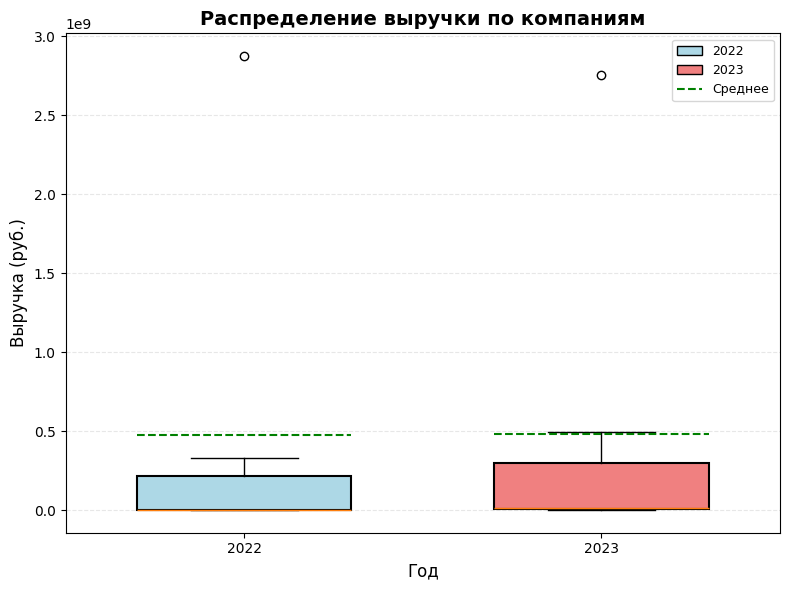

📊 Статистика выручки по годам:

2022 год:
  Количество компаний: 7
  Минимум: 644,115 руб.
  Q1 (25%): 1,851,540 руб.
  Медиана (50%): 3,209,771 руб.
  Q3 (75%): 215,785,842 руб.
  Максимум: 2,874,037,264 руб.
  Среднее: 473,309,416 руб.

2023 год:
  Количество компаний: 7
  Минимум: 1,318,962 руб.
  Q1 (25%): 8,754,982 руб.
  Медиана (50%): 10,667,978 руб.
  Q3 (75%): 299,604,554 руб.
  Максимум: 2,753,475,003 руб.
  Среднее: 483,168,716 руб.


In [22]:
# Задание 9: Boxplot распределения выручки по годам

# 1. Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# 2. Извлекаем данные за оба года
revenue_2022 = revenue[:, 0]  # столбец 0 — 2022 год
revenue_2023 = revenue[:, 1]  # столбец 1 — 2023 год

# 3. Создаём фигуру с подходящим размером
plt.figure(figsize=(8, 6))

# 4. Подготавливаем данные для boxplot
# Удаляем NaN значения, так как boxplot не работает с пропусками
data_to_plot = [
    revenue_2022[~np.isnan(revenue_2022)],  # валидные данные 2022
    revenue_2023[~np.isnan(revenue_2023)]   # валидные данные 2023
]

# 5. Строим boxplot (ИСПРАВЛЕНО: убран параметр colors)
# tick_labels — подписи для каждой коробки (новое имя в Matplotlib 3.9+)
# patch_artist=True — позволяет закрашивать коробки
bp = plt.boxplot(data_to_plot,
            tick_labels=['2022', '2023'],  # ИСПРАВЛЕНО: labels → tick_labels
            patch_artist=True,
            showmeans=True,
            meanline=True,
            meanprops={'color': 'green', 'linestyle': '--', 'linewidth': 1.5},
            notch=False,
            widths=0.6)

# 6. Устанавливаем цвета для каждого бокса отдельно (ИСПРАВЛЕНО)
colors = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# 7. Добавляем подписи осей и заголовок
plt.xlabel('Год', fontsize=12)
plt.ylabel('Выручка (руб.)', fontsize=12)
plt.title('Распределение выручки по компаниям', fontsize=14, fontweight='bold')

# 8. Добавляем сетку по оси Y для удобства чтения
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 9. Добавляем легенду с пояснением элементов
# Создаём искусственные элементы для легенды
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='black', label='2022'),
    Patch(facecolor='lightcoral', edgecolor='black', label='2023'),
    plt.Line2D([0], [0], color='green', linestyle='--', linewidth=1.5, label='Среднее')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=9, frameon=True)

# 10. Оптимизируем расположение элементов
plt.tight_layout()

# 11. Показываем график
plt.show()

# 12. Выводим статистические показатели для справки
print("📊 Статистика выручки по годам:")
print("\n2022 год:")
valid_2022 = revenue_2022[~np.isnan(revenue_2022)]
print(f"  Количество компаний: {len(valid_2022)}")
print(f"  Минимум: {np.min(valid_2022):,.0f} руб.")
print(f"  Q1 (25%): {np.percentile(valid_2022, 25):,.0f} руб.")
print(f"  Медиана (50%): {np.median(valid_2022):,.0f} руб.")
print(f"  Q3 (75%): {np.percentile(valid_2022, 75):,.0f} руб.")
print(f"  Максимум: {np.max(valid_2022):,.0f} руб.")
print(f"  Среднее: {np.mean(valid_2022):,.0f} руб.")

print("\n2023 год:")
valid_2023 = revenue_2023[~np.isnan(revenue_2023)]
print(f"  Количество компаний: {len(valid_2023)}")
print(f"  Минимум: {np.min(valid_2023):,.0f} руб.")
print(f"  Q1 (25%): {np.percentile(valid_2023, 25):,.0f} руб.")
print(f"  Медиана (50%): {np.median(valid_2023):,.0f} руб.")
print(f"  Q3 (75%): {np.percentile(valid_2023, 75):,.0f} руб.")
print(f"  Максимум: {np.max(valid_2023):,.0f} руб.")
print(f"  Среднее: {np.mean(valid_2023):,.0f} руб.")

### Задание 10
Сохраните любой построенный график в файл `econ_plot.png` (dpi=150) и проверьте, что файл появился.

In [23]:
# Задание 10: Сохранение графика в файл

# 1. Импортируем необходимые модули
import matplotlib.pyplot as plt
import os

# 2. Создаём простой график для сохранения (можно использовать любой из предыдущих)
# Например: суммарная выручка по годам
total_revenue_2022 = np.nansum(revenue[:, 0])
total_revenue_2023 = np.nansum(revenue[:, 1])
total_revenue = [total_revenue_2022, total_revenue_2023]

# 3. Создаём фигуру
plt.figure(figsize=(8, 5))

# 4. Строим линейный график
plt.plot(years, total_revenue, marker='o', linewidth=2, color='steelblue', label='Суммарная выручка')

# 5. Добавляем подписи и оформление
plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарная выручка (руб.)', fontsize=12)
plt.title('Динамика суммарной выручки компаний', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)

# 6. Оптимизируем расположение элементов
plt.tight_layout()

# 7. СОХРАНЯЕМ ГРАФИК В ФАЙЛ (КЛЮЧЕВАЯ СТРОКА ЗАДАНИЯ!)
# 'econ_plot.png' — имя файла
# dpi=150 — разрешение изображения (точек на дюйм)
# bbox_inches='tight' — обрезает лишние пустые поля вокруг графика
plt.savefig('econ_plot.png', dpi=150, bbox_inches='tight')

# 8. Закрываем фигуру, чтобы освободить память
plt.close()

# 9. ПРОВЕРЯЕМ, ЧТО ФАЙЛ ПОЯВИЛСЯ
filename = 'econ_plot.png'
if os.path.exists(filename):
    # Получаем размер файла в байтах и конвертируем в КБ
    file_size = os.path.getsize(filename) / 1024
    print(f"✅ Файл '{filename}' успешно создан!")
    print(f"📁 Размер файла: {file_size:.1f} КБ")
    print(f"📍 Путь к файлу: {os.path.abspath(filename)}")
else:
    print(f"❌ Ошибка: файл '{filename}' не был создан!")

# 10. Дополнительная информация: список файлов в текущей директории
print(f"\n📋 Файлы в текущей папке (первые 10):")
for f in sorted(os.listdir('.'))[:10]:
    print(f"  • {f}")

✅ Файл 'econ_plot.png' успешно создан!
📁 Размер файла: 67.8 КБ
📍 Путь к файлу: /content/drive/MyDrive/цифровая кафедра/econ_plot.png

📋 Файлы в текущей папке (первые 10):
  • econ_plot.png
  • Копия 1 Атомэнергопром.xlsx
  • Копия 10 ТНС_ЭНЭРГО_Карелия.xlsx
  • Копия 2 Аэрофлот.xlsx
  • Копия 3 Газпром_петрозаводск.xlsx
  • Копия 4 Лукойл.xlsx
  • Копия 5 Роснефть.xlsx
  • Копия 6 Самолет.xlsx
  • Копия 7 Славмо.xlsx
  • Копия 8 Строительная_компания_Век.xlsx


### Задание 11
Постройте scatter в лог-шкале X: используйте `np.log1p` от выручки 2023 по оси X, прибыль 2023 по оси Y.

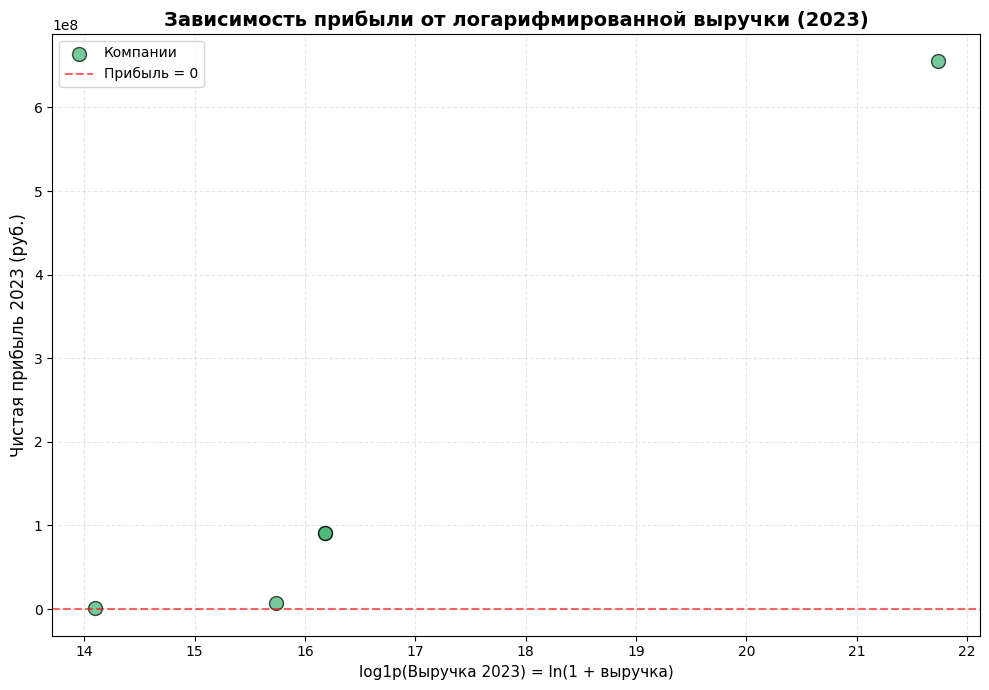

📊 Статистика данных (2023):
  Компаний с валидными данными: 5

  Выручка (оригинал):
    Мин: 1,318,962 руб.
    Макс: 2,753,475,003 руб.
  Выручка (log1p):
    Мин: 14.09
    Макс: 21.74

  Прибыль:
    Мин: 870,349 руб.
    Макс: 655,289,456 руб.
    Компаний с убытком: 0


In [24]:
# Задание 11: Scatter в лог-шкале по X (np.log1p от выручки)

# 1. Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# 2. Извлекаем данные за 2023 год (столбец с индексом 1)
revenue_2023 = revenue[:, 1]      # Ось X (будем логарифмировать)
net_profit_2023 = net_profit[:, 1]  # Ось Y

# 3. Создаём маску валидных данных: оба значения должны быть не NaN и выручка >= 0
# np.log1p работает только с x >= -1, но для выручки ожидаем x >= 0
valid_mask = (~np.isnan(revenue_2023)) & (~np.isnan(net_profit_2023)) & (revenue_2023 >= 0)

# 4. Фильтруем данные
revenue_valid = revenue_2023[valid_mask]
profit_valid = net_profit_2023[valid_mask]

# 5. Применяем np.log1p к выручке для оси X
# log1p(x) = ln(1 + x) — более точен для малых значений, чем просто log(1+x)
log_revenue = np.log1p(revenue_valid)

# 6. Создаём фигуру с подходящим размером
plt.figure(figsize=(10, 7))

# 7. Строим scatter-график: логарифмированная выручка (X) vs прибыль (Y)
plt.scatter(log_revenue, profit_valid,
            s=100, alpha=0.7, color='mediumseagreen', edgecolors='black',
            label='Компании')

# 8. Добавляем горизонтальную линию y=0 (граница прибыли/убытка)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Прибыль = 0')

# 9. Добавляем подписи осей и заголовок
plt.xlabel('log1p(Выручка 2023) = ln(1 + выручка)', fontsize=11)
plt.ylabel('Чистая прибыль 2023 (руб.)', fontsize=12)
plt.title('Зависимость прибыли от логарифмированной выручки (2023)',
          fontsize=14, fontweight='bold')

# 10. Добавляем сетку для удобства чтения
plt.grid(True, alpha=0.3, linestyle='--')

# 11. Добавляем легенду
plt.legend(fontsize=10)

# 12. Оптимизируем расположение элементов
plt.tight_layout()

# 13. Показываем график
plt.show()

# 14. Выводим статистику для справки
print("📊 Статистика данных (2023):")
print(f"  Компаний с валидными данными: {len(log_revenue)}")
print(f"\n  Выручка (оригинал):")
print(f"    Мин: {np.min(revenue_valid):,.0f} руб.")
print(f"    Макс: {np.max(revenue_valid):,.0f} руб.")
print(f"  Выручка (log1p):")
print(f"    Мин: {np.min(log_revenue):.2f}")
print(f"    Макс: {np.max(log_revenue):.2f}")
print(f"\n  Прибыль:")
print(f"    Мин: {np.min(profit_valid):,.0f} руб.")
print(f"    Макс: {np.max(profit_valid):,.0f} руб.")
print(f"    Компаний с убытком: {np.sum(profit_valid < 0)}")

### Задание 12
Постройте две линии на одном графике: Σ выручка и Σ прибыль по годам.  
Используйте `twinx()` для второй оси.

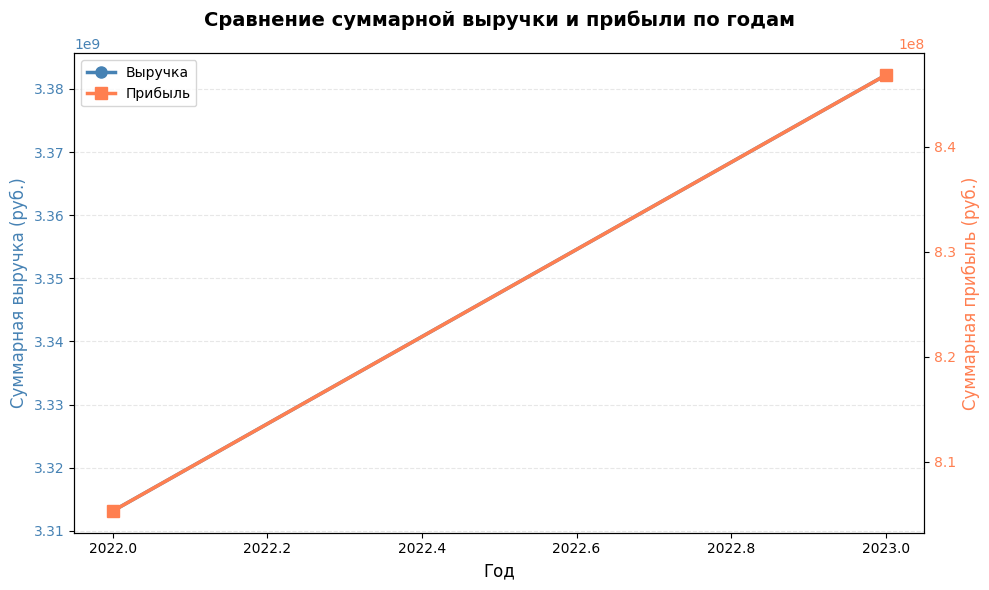

📊 Сводные данные:

  Выручка:
    2022: 3,313,165,915 руб.
    2023: 3,382,181,015 руб.
    Изменение: +69,015,100.0 руб.

  Прибыль:
    2022: 805,315,282 руб.
    2023: 846,814,937 руб.
    Изменение: +41,499,655.0 руб.

  Средняя маржа рынка:
    2022: 24.31%
    2023: 25.04%


In [25]:
# Задание 12: Две линии на одном графике с twinx()

# 1. Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# 2. Рассчитываем суммарные показатели по годам
# Используем np.nansum для игнорирования NaN значений
total_revenue = [np.nansum(revenue[:, 0]), np.nansum(revenue[:, 1])]
total_profit = [np.nansum(net_profit[:, 0]), np.nansum(net_profit[:, 1])]

# 3. Создаём фигуру и первичную ось (для выручки)
fig, ax1 = plt.subplots(figsize=(10, 6))

# 4. Строим линию выручки на первичной оси (слева)
# color='steelblue' — цвет линии и элементов оси
color_rev = 'steelblue'
ax1.set_xlabel('Год', fontsize=12)
ax1.set_ylabel('Суммарная выручка (руб.)', color=color_rev, fontsize=12)
line1 = ax1.plot(years, total_revenue,
                 marker='o', linewidth=2.5, color=color_rev,
                 label='Выручка', markersize=8)
ax1.tick_params(axis='y', labelcolor=color_rev)
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')

# 5. Создаём вторичную ось Y с помощью twinx() (для прибыли)
ax2 = ax1.twinx()

# 6. Строим линию прибыли на вторичной оси (справа)
# color='coral' — цвет линии и элементов оси
color_prof = 'coral'
ax2.set_ylabel('Суммарная прибыль (руб.)', color=color_prof, fontsize=12)
line2 = ax2.plot(years, total_profit,
                 marker='s', linewidth=2.5, color=color_prof,
                 label='Прибыль', markersize=8)
ax2.tick_params(axis='y', labelcolor=color_prof)

# 7. Добавляем общий заголовок
plt.title('Сравнение суммарной выручки и прибыли по годам',
          fontsize=14, fontweight='bold', pad=20)

# 8. Объединяем легенды с обеих осей
# Получаем метки и линии из обеих осей
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10, frameon=True)

# 9. Оптимизируем расположение элементов
plt.tight_layout()

# 10. Показываем график
plt.show()

# 11. Выводим числовые значения для справки
print("📊 Сводные данные:")
print(f"\n  Выручка:")
print(f"    2022: {total_revenue[0]:,.0f} руб.")
print(f"    2023: {total_revenue[1]:,.0f} руб.")
print(f"    Изменение: {total_revenue[1] - total_revenue[0]:+,} руб.")
print(f"\n  Прибыль:")
print(f"    2022: {total_profit[0]:,.0f} руб.")
print(f"    2023: {total_profit[1]:,.0f} руб.")
print(f"    Изменение: {total_profit[1] - total_profit[0]:+,} руб.")

# 12. Рассчитываем маржу рынка (прибыль / выручка)
margin_2022 = total_profit[0] / total_revenue[0] if total_revenue[0] != 0 else 0
margin_2023 = total_profit[1] / total_revenue[1] if total_revenue[1] != 0 else 0
print(f"\n  Средняя маржа рынка:")
print(f"    2022: {margin_2022:.2%}")
print(f"    2023: {margin_2023:.2%}")